# Проектная работа "Рыночный риск" Задания 4-8

Бородулина, Беленок, Исхакова, Ванифатов, Куликова, Гафиятуллин

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.decomposition import PCA
from typing import Union

# Задание 4 (финальный пайплайн)

In [204]:
import os

import matplotlib.dates as mdates
import scipy.stats as ss
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm
import pandas as pd

In [205]:
df = pd.read_csv('final_dataset.csv')
#df = df.drop(columns=['Unnamed: 0'])

In [206]:
columns = set(df.columns.tolist()[1:])

In [207]:
valuta = ['USD', 'EURO']

equity_tickers = [
    'AFLT', 'GAZP', 'LKOH', 'MTSS', 'PLZL', 'RIU4', 'ROSN',
    'RUAL', 'SBER', 'SIBN', 'SNGS'
]
obl_tickers = [
    'SU26233RMFS5', 'SU26248RMFS3', 'SU26212RMFS9', 'SU26228RMFS5', 'SU26230RMFS1'
]
actives = equity_tickers + obl_tickers

In [208]:
tools = actives + valuta
risks = list(columns - set(tools)) + valuta

In [209]:
risks

['COAL',
 'OIL',
 'GOLD',
 'GAS',
 'KEY_RATE',
 'RVI',
 'RTSI',
 'n_infection',
 'INFL',
 'BRILLIANT',
 'IMOEX',
 'USD',
 'EURO']

In [210]:
def divide_dataset_by_date(dataframe, date_field, training_ratio=0.8):
    # Создаем копию и сортируем по дате
    sorted_data = dataframe.copy().sort_values(date_field)

    # Определяем точку разделения
    split_index = int(len(sorted_data) * training_ratio)

    # Разделяем данные
    training_set = sorted_data.iloc[:split_index]
    evaluation_set = sorted_data.iloc[split_index:]

    return training_set, evaluation_set, sorted_data

In [211]:
training_set, evaluation_set, sorted_data = divide_dataset_by_date(df, 'date', 0.7)

In [212]:
training_set = training_set.set_index('date')
training_set = training_set.pct_change()
training_set = training_set.fillna(0)

evaluation_set = evaluation_set.set_index('date')
evaluation_set = evaluation_set.pct_change()
evaluation_set = evaluation_set.fillna(0)

sorted_data = sorted_data.set_index('date')
sorted_data = sorted_data.pct_change()
sorted_data = sorted_data.fillna(0)

In [213]:
import numpy as np

def simulate_percentage_changes(input_data, time_steps, simulations_count, seed_value=None):

    # Инициализация генератора случайных чисел
    rng = np.random.RandomState(seed_value)

    num_factors = input_data.shape[1]

    # Рассчитываем матрицу корреляций
    if num_factors > 1:
        correlation_matrix = np.corrcoef(input_data, rowvar=False)
        cholesky_decomp = np.linalg.cholesky(correlation_matrix)
    else:
        cholesky_decomp = np.eye(1)

    # Генерируем случайные нормальные величины
    random_normal_values = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(num_factors, simulations_count, time_steps)
    )

    # Накопленные изменения с поправкой на временной горизонт
    cumulative_changes = np.cumsum(
        random_normal_values / np.sqrt(time_steps),
        axis=2
    )[:, :, -1]

    # Применяем корреляционную структуру
    correlated_changes = cholesky_decomp @ cumulative_changes

    # Рассчитываем статистики входных данных
    mean_values = np.mean(input_data, axis=0)
    volatility = np.std(input_data, axis=0)

    # Вычисляем итоговые процентные изменения
    exponent_part = (mean_values - 0.5 * volatility**2) / time_steps
    risk_factor = volatility * correlated_changes.T
    percentage_changes = np.exp(exponent_part + risk_factor) - 1

    return percentage_changes

In [214]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt

В тесте Шапиро_Уилкса гипотеза о нормальности отрицается, когда p_value < 0.05

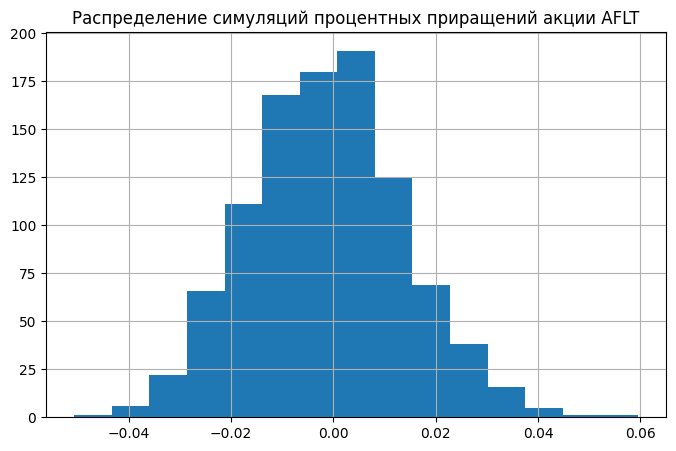

ShapiroResult(statistic=np.float64(0.9978896972429676), pvalue=np.float64(0.23947793415843155))


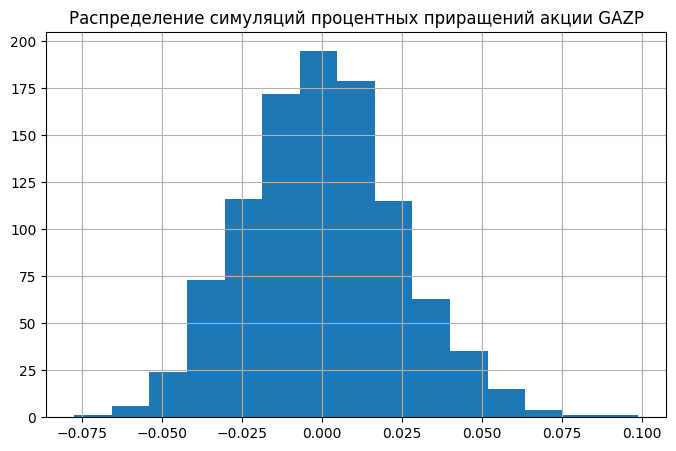

ShapiroResult(statistic=np.float64(0.9973524224417775), pvalue=np.float64(0.10210138185823953))


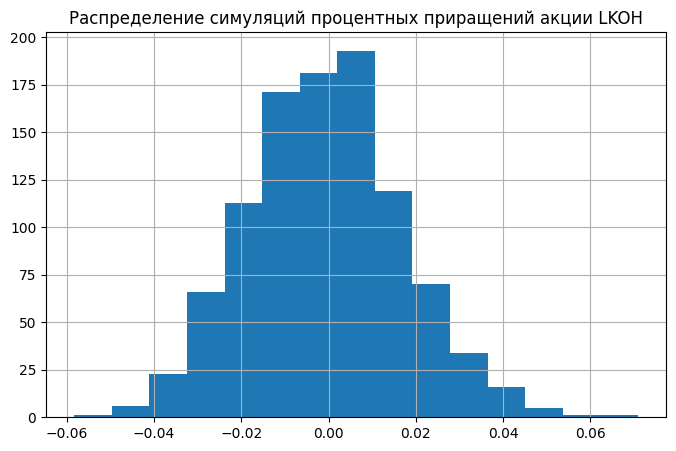

ShapiroResult(statistic=np.float64(0.9977425719777002), pvalue=np.float64(0.19081949913065133))


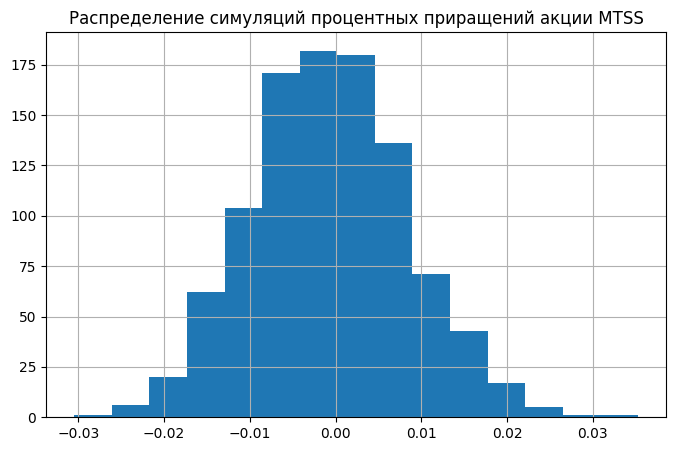

ShapiroResult(statistic=np.float64(0.9982076689016762), pvalue=np.float64(0.3807360435892938))


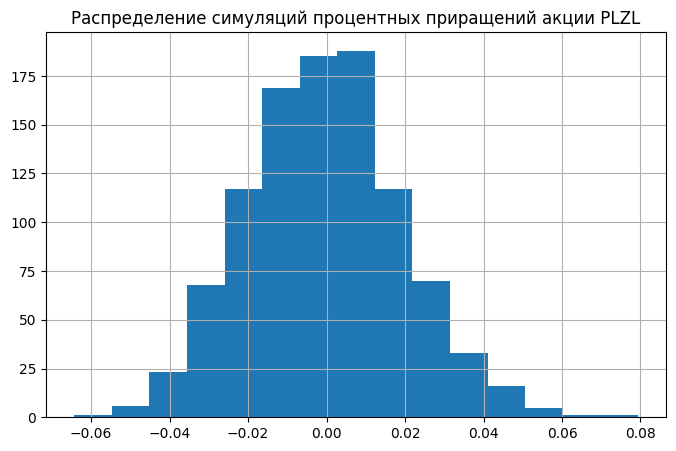

ShapiroResult(statistic=np.float64(0.9976264488706023), pvalue=np.float64(0.15887308042623965))


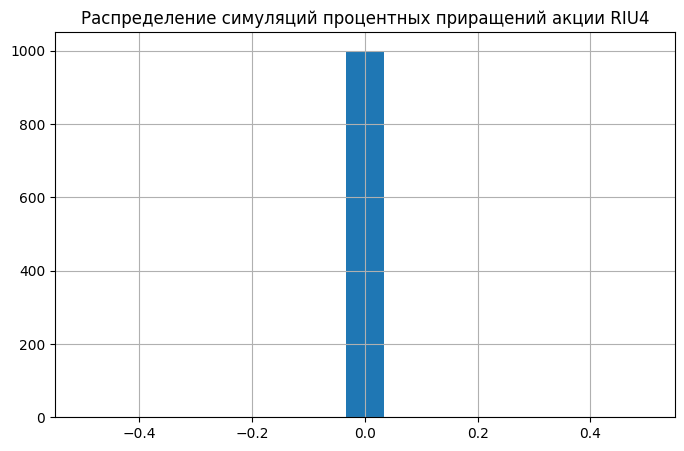

ShapiroResult(statistic=np.float64(1.0), pvalue=np.float64(1.0))


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


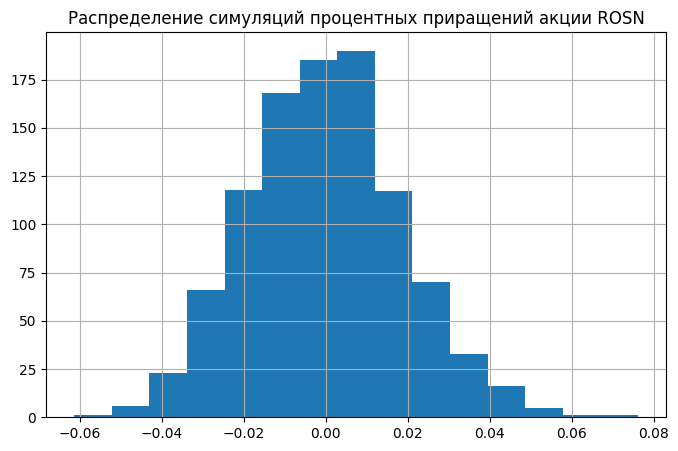

ShapiroResult(statistic=np.float64(0.99767667247563), pvalue=np.float64(0.1720392011148924))


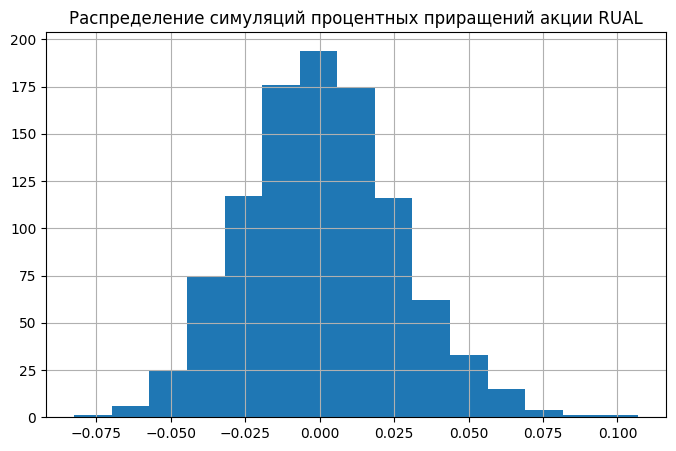

ShapiroResult(statistic=np.float64(0.9972356140808891), pvalue=np.float64(0.08432046725908789))


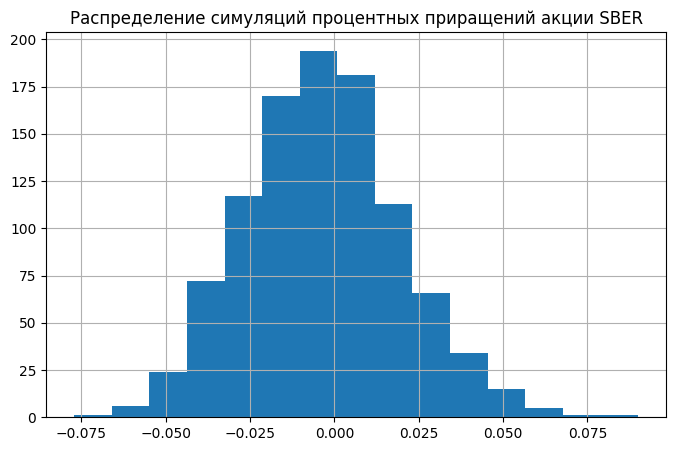

ShapiroResult(statistic=np.float64(0.9974255232542206), pvalue=np.float64(0.11500526673978978))


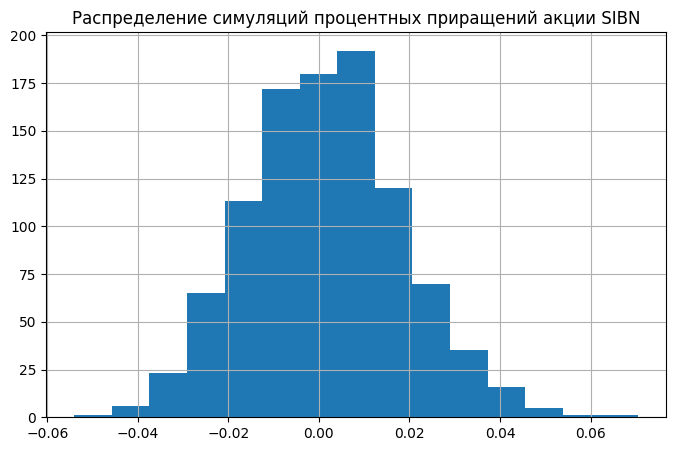

ShapiroResult(statistic=np.float64(0.9977819807271735), pvalue=np.float64(0.20291145537966848))


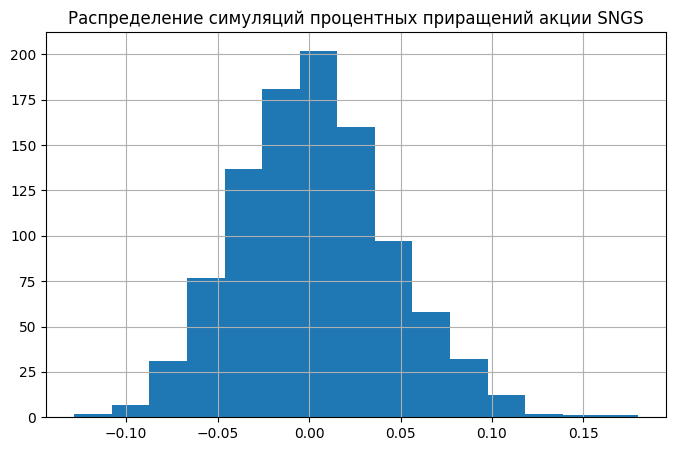

ShapiroResult(statistic=np.float64(0.9960473723557137), pvalue=np.float64(0.011846937231129047))


In [215]:
for i in equity_tickers:
  simulation = simulate_percentage_changes(input_data = sorted_data[[i]].values[200 : 200 + 60], time_steps = 1, simulations_count = 1000, seed_value = 42)
  plt.figure(figsize=(8, 5))
  plt.hist(simulation, bins=15)
  plt.title('Распределение симуляций процентных приращений акции ' + i)
  plt.grid()
  plt.show()
  print(shapiro(simulation))

In [216]:
!pip install optuna

Класс с реализацией модели

In [217]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import get_scorer, r2_score
from sklearn.model_selection import TimeSeriesSplit
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.CRITICAL)

class DimensionReductionRegressor:
    def __init__(self, pca_components=None, pca_config=None, regressor_config=None):
        self.pca_config = pca_config if pca_config else {"random_state": 42}
        self.regressor_config = regressor_config if regressor_config else {}
        self.pca_components = pca_components
        self.dim_reducer = pca_components and PCA(n_components=pca_components, **self.pca_config)
        self.regressor = LinearRegression(**self.regressor_config)
        self.feature_names = None

    def _convert_to_array(self, x):
        if self.feature_names and isinstance(x, pd.DataFrame):
            x = x[self.feature_names]
        return x.values if isinstance(x, (pd.DataFrame, pd.Series)) else x

    def train(self, features, response):
        if isinstance(features, pd.DataFrame):
            self.feature_names = features.columns.tolist()

        features = self._convert_to_array(features)
        response = self._convert_to_array(response)

        if self.dim_reducer:
            features = self.dim_reducer.fit_transform(features)

        self.regressor.fit(features, response)
        return self

    def _reduce_dimensions(self, features):
        features = self._convert_to_array(features)
        return self.dim_reducer.transform(features) if self.dim_reducer else features

    def _make_predictions(self, processed_features):
        return self.regressor.predict(processed_features)

    def predict(self, features):
        reduced_features = self._reduce_dimensions(features)
        return self._make_predictions(reduced_features)

    def __str__(self):
        return f"ReducedDimRegressor(PCA: {self.dim_reducer}, Regressor: {self.regressor})"


class SmartModelFinder:
    def __init__(self, validation_folds=5, optimization_runs=10, max_pca_features=10, scoring_func=None):
        self.cv = TimeSeriesSplit(validation_folds)
        self.optimizer = optuna.create_study(
            sampler=TPESampler(seed=42),
            direction="maximize"
        )
        self.scorer = scoring_func or r2_score
        self.optimization_runs = optimization_runs
        self.max_pca_features = max_pca_features

    def find_best_model(self, features, target):
        original_features = features
        original_target = target

        features = self._ensure_array(features)
        target = self._ensure_array(target)

        def optimization_target(trial):
            components = trial.suggest_int(
                "pca_components",
                2,
                min(self.max_pca_features, *features.shape)
            )

            cv_scores = []
            for train_index, val_index in self.cv.split(features):
                current_model = DimensionReductionRegressor(components)
                current_model.train(features[train_index], target[train_index])
                predictions = current_model.predict(features[val_index])
                score = r2_score(target[val_index], predictions)
                cv_scores.append(score)

            return np.mean(cv_scores)

        self.optimizer.optimize(optimization_target, self.optimization_runs)

        return DimensionReductionRegressor(**self.optimizer.best_params).train(original_features, original_target)

    def _ensure_array(self, data):
        return data.values if isinstance(data, (pd.DataFrame, pd.Series)) else data


    def _calculate_score(self, true_values, predicted_values):
        if self.scorer:
            return self.scorer(true_values, predicted_values)
        return r2_score(true_values, predicted_values)

In [218]:
evaluation_set.replace([np.inf, -np.inf], 0, inplace=True)
training_set.replace([np.inf, -np.inf], 0, inplace=True)
sorted_data.replace([np.inf, -np.inf], 0, inplace=True)

In [219]:
df.replace([np.inf, -np.inf], 0, inplace=True)

In [220]:
results = pd.DataFrame()
trained_models = {}

for f in equity_tickers:
    m = SmartModelFinder().find_best_model(training_set[risks], training_set[f])
    score = m.predict(training_set)
    score_test = m.predict(evaluation_set)
    results = pd.concat([results, pd.DataFrame({"tool": [f],"n_components": [m.pca_components],
                                   "r2_train": [r2_score(training_set[f], score)], "r2_test": [r2_score(evaluation_set[f], score_test)]})])
    trained_models[f] = m
results = pd.DataFrame(results)
results

,tool,n_components,r2_train,r2_test
0,AFLT,7,0.398847,0.234314
0,GAZP,8,0.458445,0.439867
0,LKOH,9,0.534694,0.384276
0,MTSS,7,0.298250,0.306164
0,PLZL,10,0.368670,0.212473
0,RIU4,5,1.000000,-0.000115
0,ROSN,9,0.667768,0.513582
0,RUAL,2,0.105623,-0.020986
0,SBER,8,0.582030,0.498155
0,SIBN,10,0.581781,0.325291


In [221]:
results = pd.DataFrame()

for f in obl_tickers + valuta:
    m = SmartModelFinder().find_best_model(training_set[risks], training_set[f])
    score = m.predict(training_set)
    score_test = m.predict(evaluation_set)
    results = pd.concat([results, pd.DataFrame({"tool": [f],"n_components": [m.pca_components],
                                   "r2_train": [r2_score(training_set[f], score)], "r2_test": [r2_score(evaluation_set[f], score_test)]})])
    trained_models[f] = m
results = pd.DataFrame(results)
results

,tool,n_components,r2_train,r2_test
0,SU26233RMFS5,10,0.433315,0.158082
0,SU26248RMFS3,5,1.000000,-0.000417
0,SU26212RMFS9,10,0.486677,0.144542
0,SU26228RMFS5,7,0.301190,0.187281
0,SU26230RMFS1,10,0.396369,0.219812
0,USD,10,0.951036,0.967771
0,EURO,10,0.955735,0.967019


# Задание 5-6

In [222]:
import pandas as pd
import numpy as np

df = pd.read_csv('final_dataset.csv')

In [223]:
df.dtypes

,0
date,object
AFLT,float64
GAZP,float64
IMOEX,float64
LKOH,float64
MTSS,float64
PLZL,float64
RIU4,float64
ROSN,float64
RTSI,float64


Классы Инструмент и портфель

In [224]:
class Tool:

    def __init__(self, name, amount, price):
        self.name = name
        self.amount = amount
        self.price = price

    def cost(self):
        return self.price * self.amount


class Portfolio:

    def __init__(self, tools, prices):

        total_cost = sum(tools.values())

        self.tools_weights = {name: cost / total_cost for name, cost in tools.items()}

        self.portfolio_tools = {
            name: Tool(name, tools[name] / prices[name],
                       prices[name]) for name, weight in self.tools_weights.items()
        }


    def portfolio_cost(self):

        return sum([x.cost() for x in self.portfolio_tools.values()])

    def rebalance_portfolio(self, updated_prices):

        old_portfolio_cost = self.portfolio_cost()

        old_prices = {name: self.portfolio_tools[name].price
                      for name in self.portfolio_tools.keys()}

        for name, price in updated_prices.items():

            self.portfolio_tools[name].price = price

        new_portfolio_cost = self.portfolio_cost()

        for name in self.portfolio_tools.keys():

            self.portfolio_tools[name].amount = self.portfolio_tools[name].amount * \
                                                ((new_portfolio_cost / updated_prices[name]) / (old_portfolio_cost / old_prices[name]))

        for name in self.portfolio_tools.keys():
            assert np.abs(self.get_tool_weight(name) - self.tools_weights[name]) < 0.00001


    def get_tool_weight(self, tool_name):

        total_cost = self.portfolio_cost()

        return self.portfolio_tools[tool_name].cost() / total_cost


    def estimate_cost(self, new_prices):
        new_cost = sum([v.amount * new_prices[name] for name, v in self.portfolio_tools.items()])
        return new_cost


In [225]:
tools = {
    'AFLT':	1_000_000,
    'GAZP':	1_000_000,
    'LKOH':	1_000_000,
    'MTSS':	1_000_000,
    'PLZL':	1_000_000,
    'ROSN':	1_000_000,
    'RUAL':	1_000_000,
    'SBER':	1_000_000,
    'SIBN':	1_000_000,
    'SNGS':	1_000_000,
    'SU26212RMFS9':	10_000_000,
    'SU26228RMFS5': 10_000_000,
    'SU26230RMFS1':	10_000_000,
    'SU26233RMFS5':	10_000_000,
    'SU26248RMFS3':	10_000_000,
    'USD': 100_000_000,
    'EURO': 100_000_000
}

In [226]:
portfolio = Portfolio(tools, df.iloc[0][tools.keys()])
portfolio_costs = []

for i in range(df.shape[0]):

  portfolio.rebalance_portfolio(df.loc[i, tools.keys()])

  portfolio_costs.append({"date": i, "cost": portfolio.portfolio_cost()})

portfolio_costs = pd.DataFrame(portfolio_costs)
portfolio_costs["cost_change"] = portfolio_costs["cost"].pct_change()

In [227]:
import matplotlib.pyplot as plt

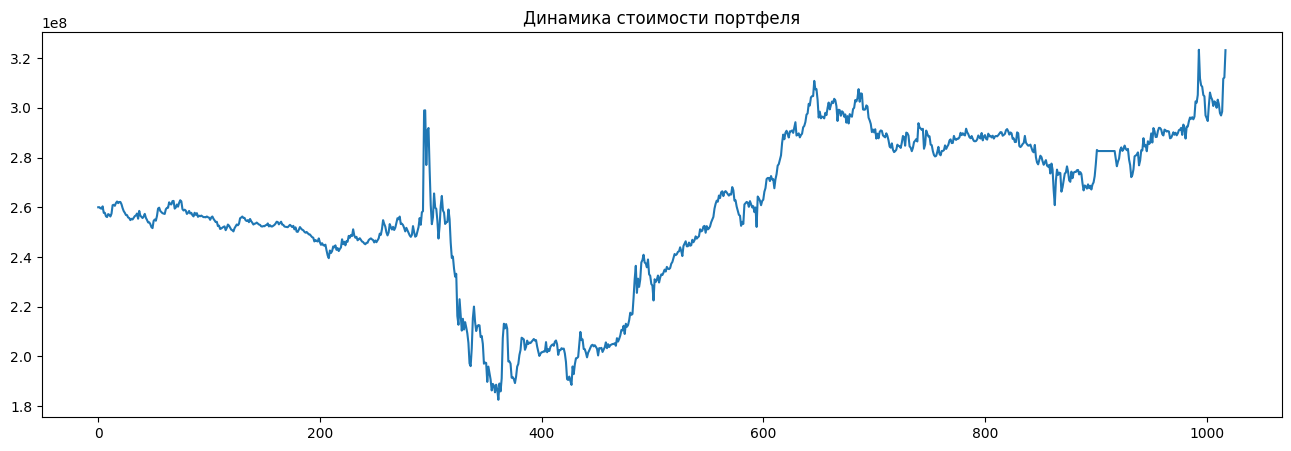

In [228]:
plt.figure(figsize = (16, 5))

plt.plot(portfolio_costs['date'], portfolio_costs['cost'])
plt.title("Динамика стоимости портфеля")
plt.show()

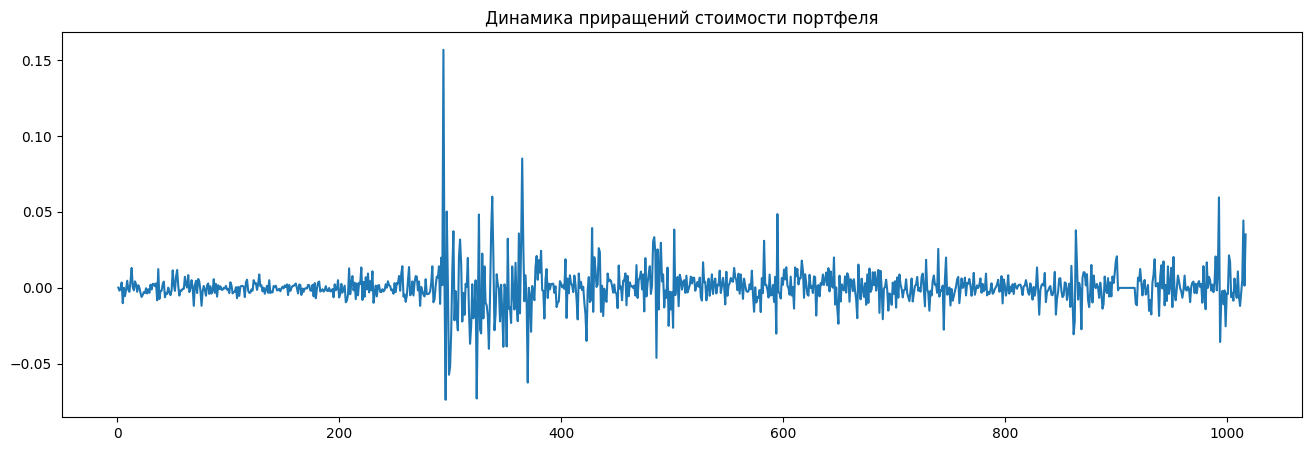

In [229]:
plt.figure(figsize = (16, 5))

plt.plot(portfolio_costs['date'], portfolio_costs['cost_change'])
plt.title("Динамика приращений стоимости портфеля")
plt.show()

In [230]:
valuta = ['USD', 'EURO']

equity_tickers = [
    'AFLT', 'GAZP', 'LKOH', 'MTSS', 'PLZL', 'RIU4', 'ROSN',
    'RUAL', 'SBER', 'SIBN', 'SNGS'
]
obl_tickers = [
    'SU26233RMFS5', 'SU26248RMFS3', 'SU26212RMFS9', 'SU26228RMFS5', 'SU26230RMFS1'
]
actives = equity_tickers + obl_tickers

Класс для симуляции портфеля

In [231]:
import numpy as np
import pandas as pd
from scipy.stats import chi2, binomtest
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm

class InvestmentPortfolioAnalyzer:
    def __init__(self, initial_assets, lookback_window, forecast_horizon):
        self.assets = initial_assets
        self.window = lookback_window
        self.horizon = forecast_horizon

        # Инициализация портфеля
        self.portfolio = Portfolio(
            initial_assets,
            df.iloc[0][initial_assets.keys()].to_dict()
        )

        # Расчет исторической динамики портфеля
        self._compute_historical_performance()

        # Генерация сценариев изменения активов
        self._generate_asset_scenarios()

        # Расчет рисковых метрик
        self._compute_risk_metrics()

        # Сопоставление с фактическими доходностями
        self.actual_returns = (
            self.historical_performance
            .dropna()
            .iloc[self.window + self.horizon:]
            ['returns']
            .reset_index(drop=True))

    def _compute_historical_performance(self):
        performance_records = []

        for date, row in tqdm(df.iterrows(), total=len(df)):
            self.portfolio.rebalance_portfolio(row[self.assets.keys()].to_dict())
            performance_records.append({
                "date": date,
                "value": self.portfolio.portfolio_cost(),
            })

        self.historical_performance = pd.DataFrame(performance_records)
        self.historical_performance["returns"] = self.historical_performance["value"].pct_change()

    def _generate_asset_scenarios(self):
        scenario_data = [None] * len(self.assets)

        # Сценарии для производных инструментов
        for idx, asset in enumerate(self.assets):
            if asset not in equity_tickers:
                model = trained_models[asset]
                factors = model._reduce_dimensions(sorted_data)
                scenarios = []

                for i in range(len(factors) - self.window - self.horizon):
                    factor_scenarios = simulate_percentage_changes(
                        factors[i:i+self.window],
                        self.horizon,
                        simulations_count=1000,
                        seed_value=42
                    )
                    scenarios.append(model._make_predictions(factor_scenarios))

                scenario_data[idx] = scenarios

        # Сценарии для акций
        if any(x is None for x in scenario_data):
            stock_data = sorted_data[[a for a in self.assets if a in equity_tickers]].values
            stock_scenarios = []

            for i in range(len(stock_data) - self.window - self.horizon):
                stock_scenarios.append(
                    simulate_percentage_changes (
                        stock_data[i:i+self.window],
                        self.horizon,
                        simulations_count=1000,
                        seed_value=42
                    )
                )

            stock_scenarios = np.array(stock_scenarios)
            stock_idx = 0

            for idx, asset in enumerate(self.assets):
                if asset in equity_tickers:
                    scenario_data[idx] = stock_scenarios[:, :, stock_idx]
                    stock_idx += 1

        self.asset_scenarios = np.array(scenario_data)

        # Расчет сценариев для портфеля
        portfolio_scenarios = []
        test_period = df.iloc[self.window + self.horizon + 1:].copy()

        temp_portfolio =Portfolio(
            self.assets,
            test_period.iloc[0].to_dict()
        )

        for scenario_idx, (date, prices) in tqdm(enumerate(test_period.iterrows()), total=len(test_period)):
            temp_portfolio.rebalance_portfolio(prices[self.assets.keys()])
            initial_value = temp_portfolio.portfolio_cost()
            scenario_returns = []

            new_prices = prices[self.assets.keys()].values * (1 + self.asset_scenarios[:, scenario_idx, :].T)

            for scenario in new_prices:
                scenario_returns.append(temp_portfolio.estimate_cost({k: v for k, v in zip(self.assets.keys(), scenario)}) / initial_value - 1)

            portfolio_scenarios.append({
                "date": date,
                "returns": scenario_returns,
            })

        self.portfolio_scenarios = pd.DataFrame(portfolio_scenarios)

    def _compute_risk_metrics(self):
        def calculate_var(returns):
            return np.percentile(returns, 1)

        def calculate_es(returns):
            var = calculate_var(returns)
            return np.mean([r for r in returns if r < var])

        self.portfolio_scenarios["var_99"] = self.portfolio_scenarios["returns"].apply(calculate_var)
        self.portfolio_scenarios["es_97,5"] = self.portfolio_scenarios["returns"].apply(calculate_es)

    def visualize_performance(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

        self.historical_performance.plot(x="date", y="value", ax=ax1)
        ax1.set_title("Portfolio Value Over Time")
        ax1.grid(True)

        self.historical_performance.dropna().plot(x="date", y="returns", ax=ax2)
        ax2.set_title("Portfolio Returns Over Time")
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

    def backtest_risk_model(self, risk_metric, metric_name, color="red", confidence=0.99):
        breaches = self.actual_returns < self.portfolio_scenarios[risk_metric]
        breach_count = breaches.sum()
        total_days = len(breaches)

        print(f"Risk Metric: {metric_name}")
        print(f"Breach Count: {breach_count}")
        print(f"Breach Rate: {breach_count/total_days:.4f}")

        # Binomial tests
        print("\nBinomial Tests:")
        two_sided = binomtest(breach_count, total_days, 1-confidence, alternative="two-sided")
        print(f"Two-sided p-value: {two_sided.pvalue:.4f}")

        one_sided = binomtest(breach_count, total_days, 1-confidence, alternative="greater")
        print(f"One-sided p-value: {one_sided.pvalue:.4f}")

        #Kupiec POF test
        print("\nKupiec POF Test:")
        test_result = self._run_kupiec_test(breach_count, total_days, confidence)
        for k, v in test_result.items():
            print(f"{k}: {v}")

        # Visualization
        plt.figure(figsize=(15, 4))
        dates = self.portfolio_scenarios["date"]
        plt.plot(dates, self.actual_returns, label="Actual Returns")
        plt.plot(dates, self.portfolio_scenarios[risk_metric], c="r", alpha=0.4, label=metric_name)

        breach_dates = dates[breaches]
        plt.scatter(breach_dates, self.actual_returns[breaches], c=color)

        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
        plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
        plt.title(f"Portfolio Returns vs {metric_name}")
        plt.ylabel("Returns")
        plt.grid()
        plt.legend()
        plt.show()

    def _run_kupiec_test(self, breaches, total, confidence):
        expected = (1 - confidence) * total
        actual_rate = breaches / total

        if breaches == 0:
            lr = -2 * np.log((1 - confidence) ** total)
        else:
            lr = 2 * (np.log(actual_rate**breaches * (1-actual_rate)**(total-breaches)) -
                     np.log((1-confidence)**(total-breaches) * confidence**breaches))

        p_value = 1 - chi2.cdf(lr, df=1)
        reject = p_value < 0.05

        return {
            'test_statistic': lr,
            'p_value': p_value,
            'reject_null': reject,
            'actual_breach_rate': actual_rate,
            'expected_breach_rate': 1 - confidence
        }



Период симуляции - 1 день

100%|██████████| 956/956 [00:06<00:00, 150.65it/s]


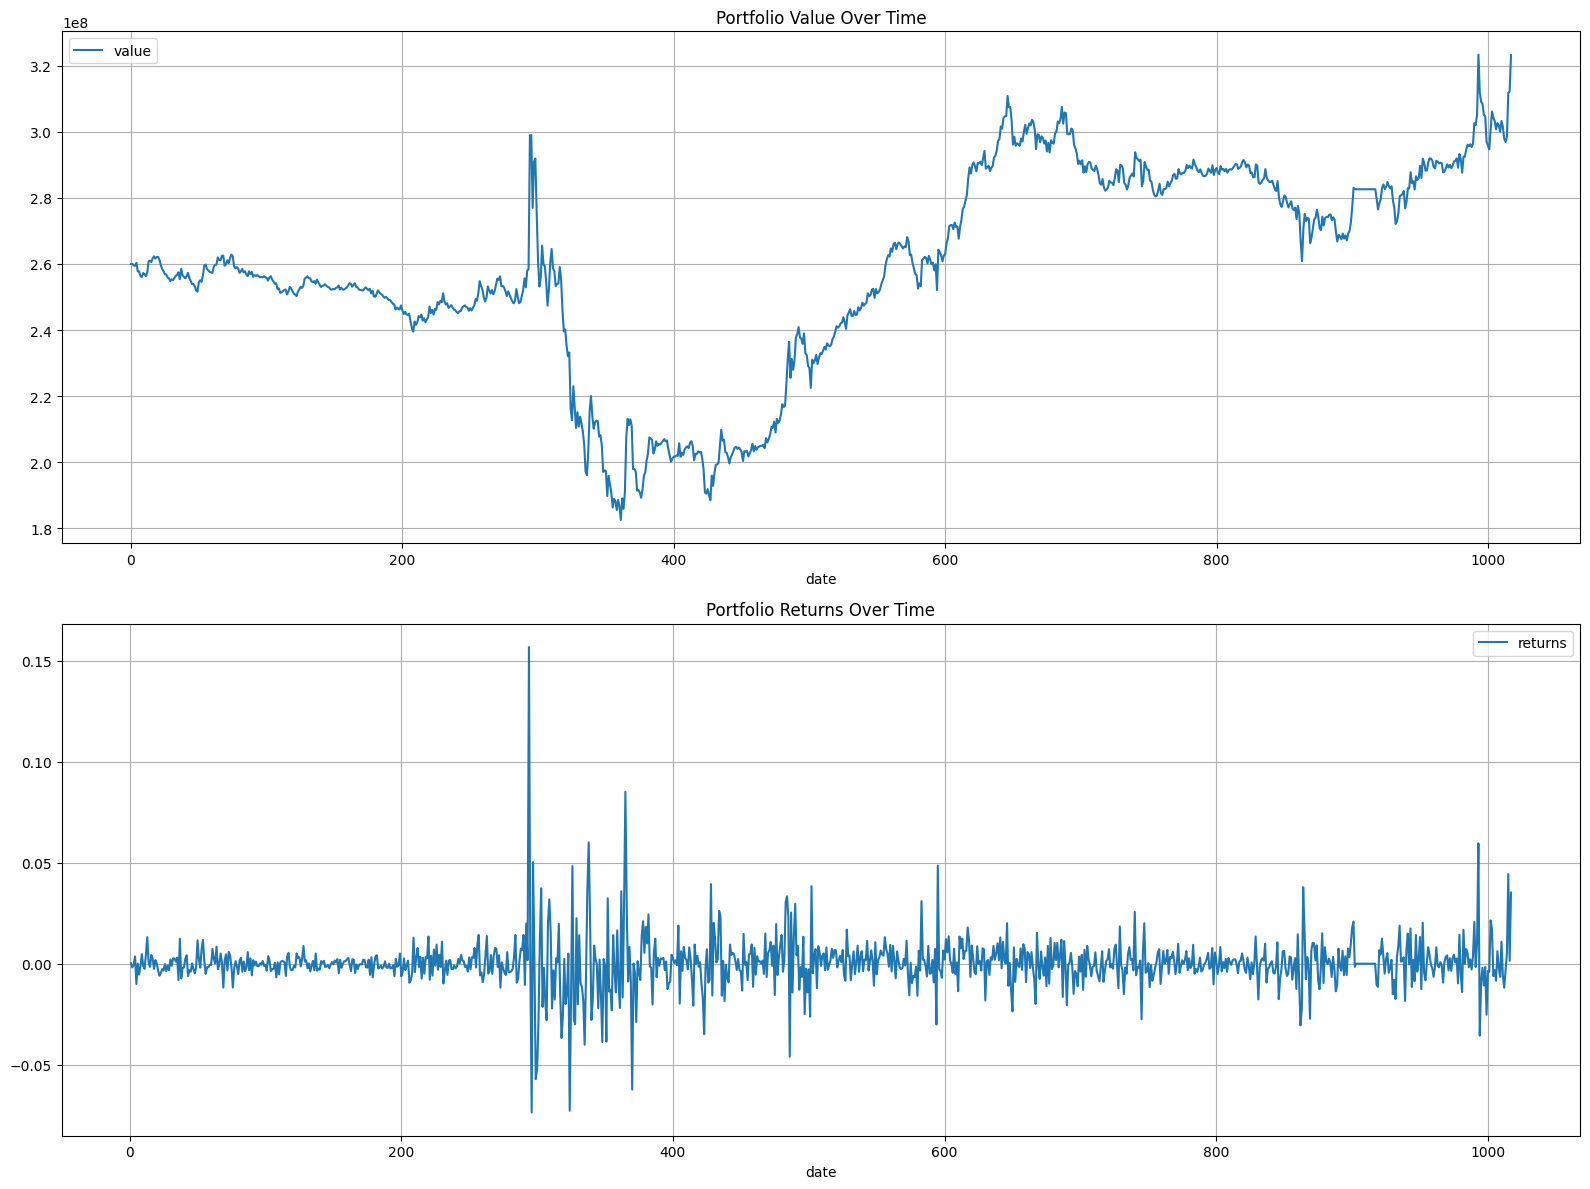

Risk Metric: VAR 99
Breach Count: 27
Breach Rate: 0.0282

Binomial Tests:
Two-sided p-value: 0.0000
One-sided p-value: 0.0000

Kupiec POF Test:
test_statistic: inf
p_value: 0.0
reject_null: True
actual_breach_rate: 0.028242677824267783
expected_breach_rate: 0.010000000000000009


/tmp/ipython-input-231-1792953383.py:195: RuntimeWarning: divide by zero encountered in log
  np.log((1-confidence)**(total-breaches) * confidence**breaches))


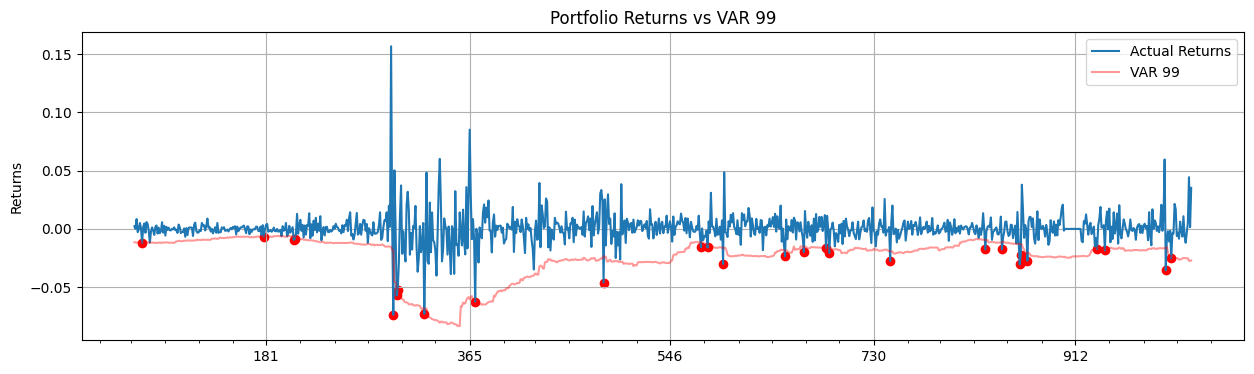

Risk Metric: ES 97,5
Breach Count: 18
Breach Rate: 0.0188

Binomial Tests:
Two-sided p-value: 0.0130
One-sided p-value: 0.0091

Kupiec POF Test:
test_statistic: inf
p_value: 0.0
reject_null: True
actual_breach_rate: 0.01882845188284519
expected_breach_rate: 0.010000000000000009


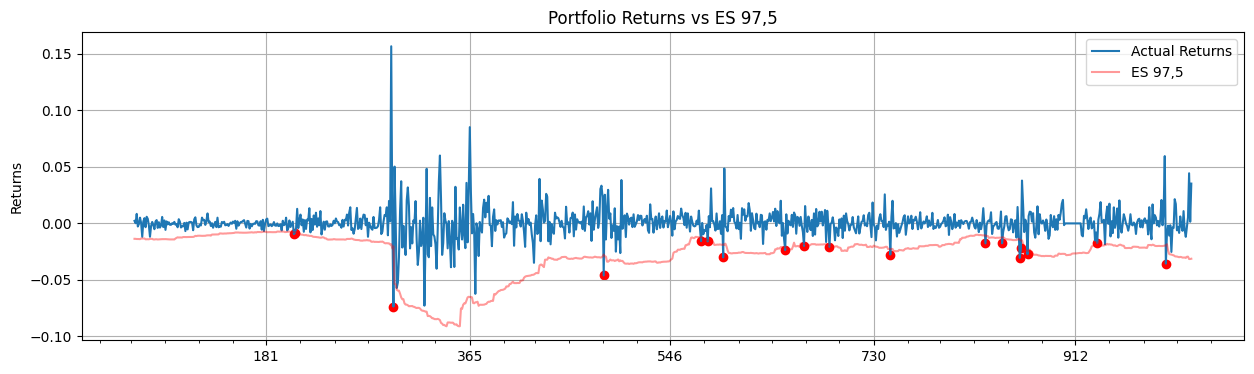

In [232]:
tools = {
    'AFLT':	1_000_000,
    'GAZP':	1_000_000,
    'LKOH':	1_000_000,
    'MTSS':	1_000_000,
    'PLZL':	1_000_000,
    'ROSN':	1_000_000,
    'RUAL':	1_000_000,
    'SBER':	1_000_000,
    'SIBN':	1_000_000,
    'SNGS':	1_000_000,
    'SU26212RMFS9':	10_000_000,
    'SU26228RMFS5': 10_000_000,
    'SU26230RMFS1':	10_000_000,
    'SU26233RMFS5':	10_000_000,
    'SU26248RMFS3':	10_000_000,
    'USD': 100_000_000,
    'EURO': 100_000_000
}

ps = InvestmentPortfolioAnalyzer(tools, 60, 1)
ps.visualize_performance()
ps.backtest_risk_model("var_99", "VAR 99", "r", 0.99)
ps.backtest_risk_model("es_97,5", "ES 97,5", "r", 0.99)

Период симуляции - 10 дней

100%|██████████| 947/947 [00:07<00:00, 123.81it/s]


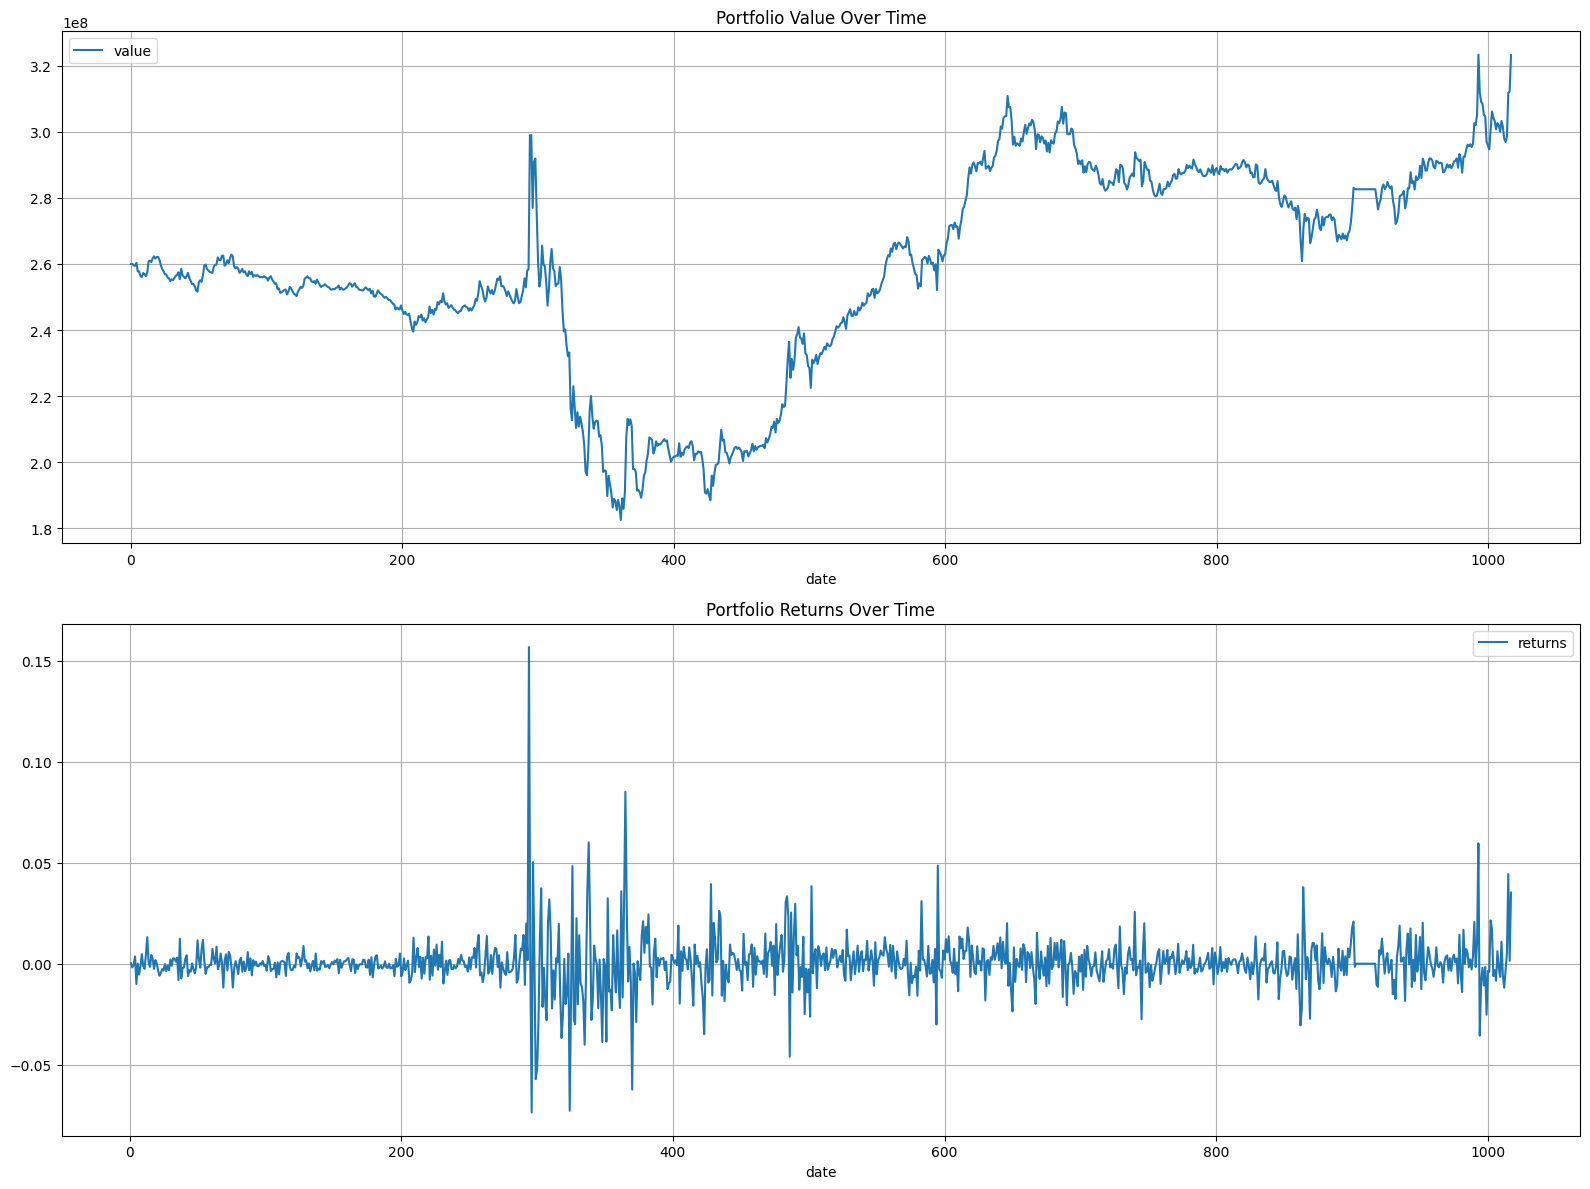

Risk Metric: VAR 99
Breach Count: 29
Breach Rate: 0.0306

Binomial Tests:
Two-sided p-value: 0.0000
One-sided p-value: 0.0000

Kupiec POF Test:
test_statistic: inf
p_value: 0.0
reject_null: True
actual_breach_rate: 0.030623020063357972
expected_breach_rate: 0.010000000000000009


/tmp/ipython-input-231-1792953383.py:195: RuntimeWarning: divide by zero encountered in log
  np.log((1-confidence)**(total-breaches) * confidence**breaches))


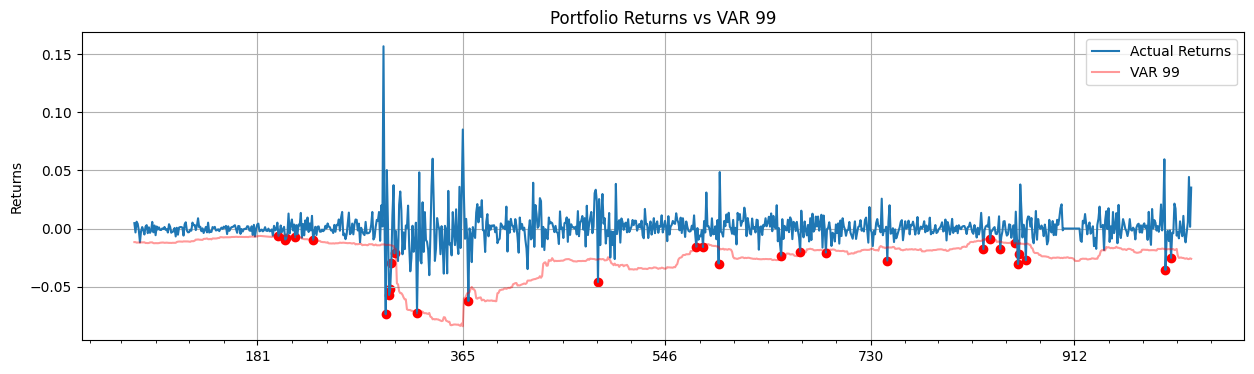

Risk Metric: ES 97,5
Breach Count: 19
Breach Rate: 0.0201

Binomial Tests:
Two-sided p-value: 0.0047
One-sided p-value: 0.0040

Kupiec POF Test:
test_statistic: inf
p_value: 0.0
reject_null: True
actual_breach_rate: 0.02006335797254488
expected_breach_rate: 0.010000000000000009


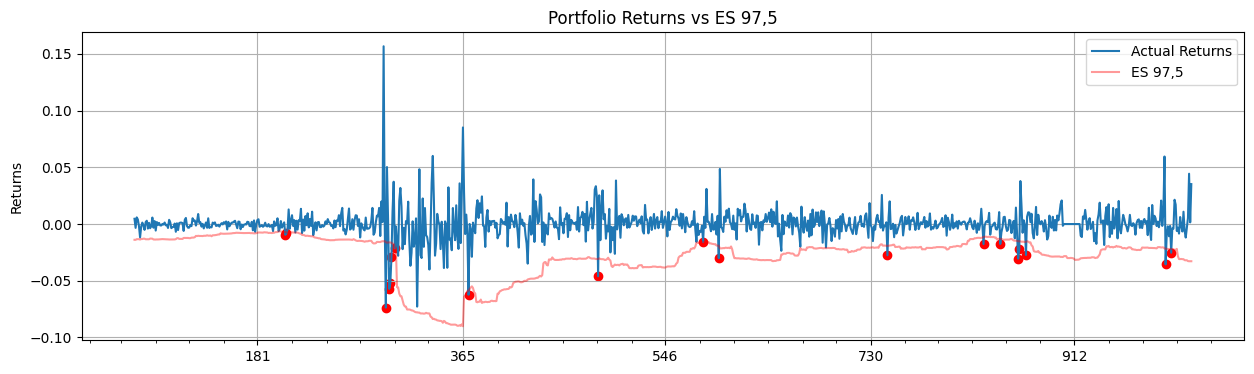

In [233]:
tools = {
    'AFLT':	1_000_000,
    'GAZP':	1_000_000,
    'LKOH':	1_000_000,
    'MTSS':	1_000_000,
    'PLZL':	1_000_000,
    'ROSN':	1_000_000,
    'RUAL':	1_000_000,
    'SBER':	1_000_000,
    'SIBN':	1_000_000,
    'SNGS':	1_000_000,
    'SU26212RMFS9':	10_000_000,
    'SU26228RMFS5': 10_000_000,
    'SU26230RMFS1':	10_000_000,
    'SU26233RMFS5':	10_000_000,
    'SU26248RMFS3':	10_000_000,
    'USD': 100_000_000,
    'EURO': 100_000_000
}

ps = InvestmentPortfolioAnalyzer(tools, 60, 10)
ps.visualize_performance()
ps.backtest_risk_model("var_99", "VAR 99", "r", 0.99)
ps.backtest_risk_model("es_97,5", "ES 97,5", "r", 0.99)

#7 задание



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.decomposition import PCA
from typing import Union

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
var_es = pd.read_csv('/content/var_es.csv')

In [ ]:
var = var_es['var_99'].tail(251)

In [ ]:
returns = pd.read_csv('/content/returns.csv')
returns

,Unnamed: 0,price_change
0,0,0.002216
1,1,0.000165
2,2,0.008430
3,3,-0.002762
4,4,-0.000483
...,...,...
951,951,-0.003283
952,952,0.005310
953,953,0.044370
954,954,0.001471


In [ ]:
ret = returns.iloc[:, 1].tail(251)

In [ ]:
seven = pd.concat([var, ret], axis=1)
seven['check'] = np.where(seven['var_99'] > seven['price_change'], 1, 0)

In [ ]:
import numpy as np
from scipy.stats import binom

def kupiec_test(check_column, alpha=0.01, confidence_level=0.99):
    exceptions = check_column.sum()
    total = len(check_column)
    expected = alpha * total
    LR_stat = -2 * (np.log((1-alpha)**(total-exceptions) * alpha**exceptions) -
               np.log((1 - exceptions/total)**(total-exceptions) * (exceptions/total)**exceptions))
    from scipy.stats import chi2
    critical_value = chi2.ppf(confidence_level, df=1)
    p_value = 1 - chi2.cdf(LR_stat, df=1)
    if LR_stat < critical_value:
        result = "Отклоняем H0: Модель VaR неадекватна"
    else:
        result = "Не отклоняем H0: Модель VaR для теста Kupiec адекватна"

    return {'Результат': result}


kupiec_results = kupiec_test(seven['check'])
kupiec_results

{'Результат': 'Не отклоняем H0: Модель VaR для теста Kupiec адекватна'}

Если нулевая гипотеза в тесте Купика не отвергается, это означает, что модель VaR корректно оценивает вероятность превышения убытков, и количество наблюдаемых превышений соответствует ожидаемому уровню.

In [ ]:
if isinstance(var_es['price_change'].iloc[0], str):
    var_es['price_change'] = var_es['price_change'].apply(lambda x: np.fromstring(x[1:-1], sep=','))

var_es['predicted_return'] = var_es['price_change'].apply(np.mean)
print(var_es[['price_change', 'predicted_return']])

                                          price_change  predicted_return
0    [0.00580678746765817, 0.001004328906258678, -0...          0.000168
1    [0.005821303403013012, 0.0009759830890943011, ...          0.000155
2    [0.006378535391800666, -0.006311411745394735, ...          0.000335
3    [0.0064689637033372716, -0.006296513393759473,...          0.000402
4    [0.006398203179245554, -0.0063284696071791435,...          0.000377
..                                                 ...               ...
951  [0.01764595254001966, 0.00864480963138603, 0.0...          0.001405
952  [0.018025454996199564, 0.008554233421447455, 0...          0.001388
953  [0.015540791796671005, 0.008551522341189388, -...          0.000649
954  [0.015576219516653333, 0.008557577097790592, -...          0.000678
955  [0.015607248486445346, 0.008630702338579876, -...          0.000870

[956 rows x 2 columns]


In [ ]:
pred = var_es['predicted_return'].tail(251)

In [ ]:
seven['predicted'] = pred
seven.head()

,var_99,price_change,check,predicted
705,-0.018620,0.002664,0,-0.000090
706,-0.018710,0.005932,0,-0.000284
707,-0.018702,0.001582,0,-0.000239
708,-0.018657,-0.005194,0,-0.000169
709,-0.018364,0.000233,0,0.000197


In [ ]:
from scipy.stats import geom, kstest

def geometric_var_test(violation_series, alpha=0.01):
    violation_indices = np.where(violation_series == 1)[0]
    durations = np.diff(violation_indices)
    if len(durations) < 2:
        return {
            'test_statistic': np.nan,
            'p_value': np.nan,
            'result': 'Insufficient violations for test'
        }
    p = alpha
    standardized = durations * p
    ks_stat, p_value = kstest(standardized, 'expon')

    return {
        'KS_statistic': ks_stat,
        'p_value': p_value,
        'result': 'Reject H0' if p_value < 0.05 else 'Fail to reject H0'
    }

geometric_results = geometric_var_test(seven['check'], alpha=0.01)

In [ ]:
geometric_var_test(seven['check'], alpha=0.01)

{'KS_statistic': np.float64(0.6021437889662113),
 'p_value': np.float64(0.002641004279288946),
 'result': 'Reject H0'}

In [ ]:
from scipy.stats import norm, chi2
from scipy.optimize import minimize
def berkowitz_test(actual_returns, var_values, predicted_returns=None, alpha=0.01):
    actual = np.asarray(actual_returns)
    var = np.asarray(var_values)
    violations = actual < var
    n = len(actual)
    k = violations.sum()
    u = np.zeros(n)
    for i in range(n):
        if violations[i]:
            u[i] = alpha * np.random.uniform()
        else:
            u[i] = alpha + (1-alpha) * np.random.uniform()

    z = norm.ppf(u)

    def neg_log_likelihood(params):
        mu, sigma = params
        if sigma <= 0:
            return 1e10
        return -np.sum(norm.logpdf(z, loc=mu, scale=sigma))

    res = minimize(neg_log_likelihood, [0, 1], bounds=[(None, None), (1e-5, None)])
    mu_hat, sigma_hat = res.x

    LR = 2 * (neg_log_likelihood([0, 1]) - neg_log_likelihood([mu_hat, sigma_hat]))
    p_value = 1 - chi2.cdf(LR, df=2)

    return {
        'LR_statistic': LR,
        'p_value': p_value,
        'mu_hat': mu_hat,
        'sigma_hat': sigma_hat,
        'test_result': "Reject H0" if p_value < 0.05 else "Fail to reject H0",
        'num_observations': n,
        'num_violations': k,
        'violation_ratio': k/n,
        'z_scores': z
    }
results = berkowitz_test(
    actual_returns=seven['price_change'].values,
    var_values=seven['var_99'].values,
    predicted_returns=seven['predicted'].values if 'predicted' in seven.columns else None,
    alpha=0.01
)

print(f"Результаты теста Berkowitz:")
print(f"LR статистика: {results['LR_statistic']:.4f}")
print(f"P-value: {results['p_value']:.4f}")
print(f"Вывод: {results['test_result']}")

Результаты теста Berkowitz:
LR статистика: 3.2937
P-value: 0.1927
Вывод: Fail to reject H0


# Задание 8

In [ ]:
!pip install moexalgo pandas_market_calendars scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.1/200.1 kB 5.7 MB/s eta 0:00:00


/tmp/ipython-input-3-1674407001.py:44: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Используется ставка ЦБ 20%

Реальные параметры:
Текущая цена: 314.42 руб.
Ставка ЦБ: 20.0%
Дней до экспирации: 28

Сравнение цен:
Call 314.4:
  Рынок: 11.32 руб.
  Модель: 9.56 руб.

Put 330.1:
  Рынок: 14.67 руб.
  Модель: 13.63 руб.

Стоимость портфеля (1 млн руб. номинала):
Рыночная: 82,660.14 руб.
Модельная: 73,772.81 руб.
Разница: 8,887.33 руб.


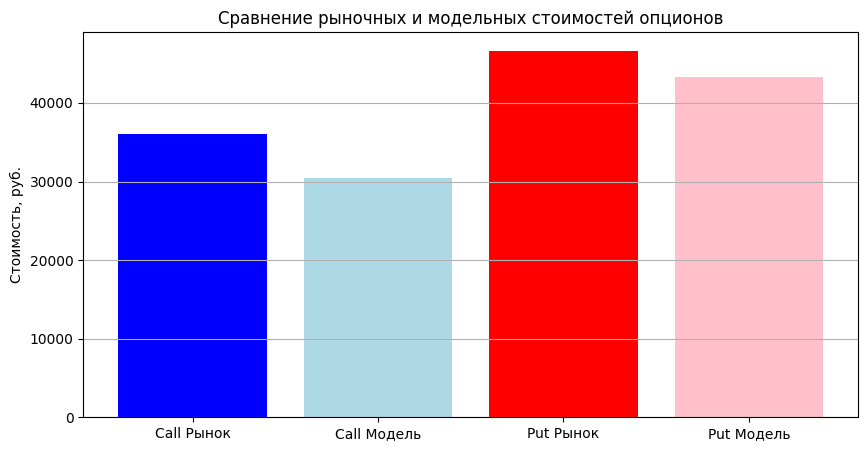

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from datetime import datetime
import requests
import matplotlib.pyplot as plt

class BlackScholes:

    def __init__(self, S: float, K: float, T: float, r: float, sigma: float, option_type: str):
        self.S = S
        self.K = K
        self.T = max(T, 1/365)
        self.r = r
        self.sigma = 0.2
        self.option_type = option_type.lower()

        self.d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
        self.d2 = self.d1 - sigma * np.sqrt(T)

    def price(self) -> float:
        if self.option_type == 'call':
            price = self.S * norm.cdf(self.d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(self.d2)
        else:
            price = self.K * np.exp(-self.r * self.T) * norm.cdf(-self.d2) - self.S * norm.cdf(-self.d1)
        return max(price, 0.01)

def get_real_volatility(ticker: str) -> float:
    """Более точный расчет волатильности"""
    try:
        url = f"https://iss.moex.com/iss/statistics/engines/stock/marketvolatility.json"
        params = {'ticker': ticker}
        response = requests.get(url, params=params, timeout=10)
        data = response.json()
        return float(data['volatility']['data'][0][1]) / 100
    except:
        return 0.2

def get_risk_free_rate() -> float:
    """Актуальная ставка ЦБ РФ"""
    try:
        url = "https://www.cbr.ru/hd_base/keyrate/"
        response = requests.get(url, timeout=10)
        tables = pd.read_html(response.text)
        return float(tables[0].iloc[-1,1].replace(',','.'))/100
    except:
        print("Используется ставка ЦБ 20%")
        return 0.2

def calculate_real_portfolio(ticker: str, call_strike: float, call_price: float,
                           put_strike: float, put_price: float, expiration: str) -> dict:
    S = 314.42
    r = get_risk_free_rate()
    sigma = get_real_volatility(ticker)

    exp_date = datetime.strptime(expiration, '%Y-%m-%d')
    T = (exp_date - datetime.now()).days / 365

    # Расчет модельных цен
    call_model = BlackScholes(S, call_strike, T, r, sigma, 'call').price()
    put_model = BlackScholes(S, put_strike, T, r, sigma, 'put').price()

    shares = 1e6 / S

    return {
        'parameters': {
            'spot_price': S,
            'volatility': sigma,
            'risk_free_rate': r,
            'days_to_expiry': (exp_date - datetime.now()).days
        },
        'call': {
            'strike': call_strike,
            'market_price': call_price,
            'model_price': call_model,
            'value_market': call_price * shares,
            'value_model': call_model * shares
        },
        'put': {
            'strike': put_strike,
            'market_price': put_price,
            'model_price': put_model,
            'value_market': put_price * shares,
            'value_model': put_model * shares
        },
        'portfolio': {
            'market_value': (call_price + put_price) * shares,
            'model_value': (call_model + put_model) * shares
        }
    }

results = calculate_real_portfolio(
    ticker="SBER",
    call_strike=314.4,
    call_price=11.32,
    put_strike=330.1,
    put_price=14.67,
    expiration="2025-07-27"
)

print(f"\nРеальные параметры:")
print(f"Текущая цена: {results['parameters']['spot_price']} руб.")
print(f"Ставка ЦБ: {results['parameters']['risk_free_rate']:.1%}")
print(f"Дней до экспирации: {results['parameters']['days_to_expiry']}")

print("\nСравнение цен:")
print(f"Call {results['call']['strike']}:")
print(f"  Рынок: {results['call']['market_price']:.2f} руб.")
print(f"  Модель: {results['call']['model_price']:.2f} руб.")

print(f"\nPut {results['put']['strike']}:")
print(f"  Рынок: {results['put']['market_price']:.2f} руб.")
print(f"  Модель: {results['put']['model_price']:.2f} руб.")

print("\nСтоимость портфеля (1 млн руб. номинала):")
print(f"Рыночная: {results['portfolio']['market_value']:,.2f} руб.")
print(f"Модельная: {results['portfolio']['model_value']:,.2f} руб.")
print(f"Разница: {results['portfolio']['market_value'] - results['portfolio']['model_value']:,.2f} руб.")

plt.figure(figsize=(10,5))
plt.bar(['Call Рынок', 'Call Модель', 'Put Рынок', 'Put Модель'],
        [results['call']['value_market'], results['call']['value_model'],
         results['put']['value_market'], results['put']['value_model']],
        color=['blue', 'lightblue', 'red', 'pink'])
plt.title("Сравнение рыночных и модельных стоимостей опционов")
plt.ylabel("Стоимость, руб.")
plt.grid(axis='y')
plt.show()